### Overannotation analysis
In this notebook we take the overannotated proteins (annotated nicely only in the tools and not in Reference) and explore the results

### 1. Importing the dataframes
Here we are importing the bacillus_concordant_CDS.csv and df_with_all_ids.csv. The last one is the final dataframe from 3_database_id_matching.

In [85]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

--- Resumo Funcional: Ferramenta vs Referência ---


<>:62: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:62: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
/tmp/ipykernel_384406/1655286740.py:62: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  plt.title("Functional Annotation comparison against Ground Truth ($\it{B. subtilis}$)", fontsize=14)


Category,Both Informative,Both Hypothetical,Over-Annotation,Under-Annotation
Tool,,,,
Bakta,2044,1481,306,409
PGAP,2396,563,1224,57
Prokka,1821,1455,332,632
eggNOG,2122,818,969,331


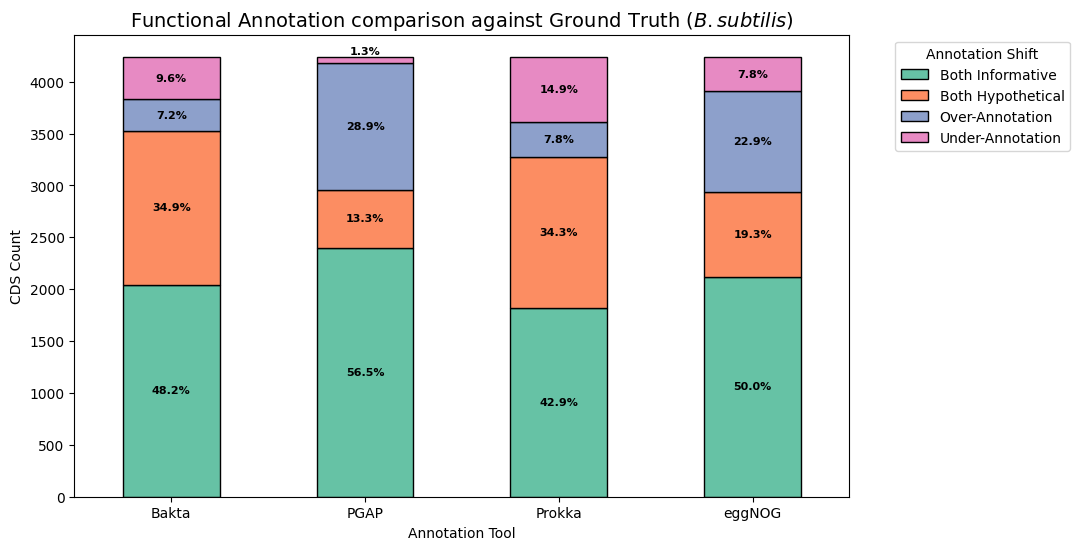

In [86]:
df_func = pd.read_csv("bacillus_data/bacillus_concordant_CDS.csv")

def is_informative(product_text):
    if pd.isna(product_text):
        return False
        
    text = str(product_text).lower().strip()
    
    vague_terms = ['hypothetical', 'uncharacterized', 'unknown', 'putative', 'duf', 'domain of unknown function']
    
    if any(term in text for term in vague_terms) or text == '':
        return False
    
    return True

tools = ['Reference', 'Prokka', 'Bakta', 'PGAP', 'eggNOG']
for tool in tools:
    col_name = f'product_{tool}'
    info_col = f'is_info_{tool}'
    df_func[info_col] = df_func[col_name].apply(is_informative)

comparison_results = []
tools_to_evaluate = ['Prokka', 'Bakta', 'PGAP', 'eggNOG']

for tool in tools_to_evaluate:
    tool_info = df_func[f'is_info_{tool}']
    ref_info = df_func['is_info_Reference']
    
    for i in range(len(df_func)):
        t_val = tool_info.iloc[i]
        r_val = ref_info.iloc[i]
        
        if t_val == True and r_val == True:
            category = 'Both Informative'
        elif t_val == False and r_val == False:
            category = 'Both Hypothetical'
        elif t_val == True and r_val == False:
            category = 'Over-Annotation'
        elif t_val == False and r_val == True:
            category = 'Under-Annotation'
            
        comparison_results.append({
            'Tool': tool,
            'Category': category
        })

df_plot = pd.DataFrame(comparison_results)
summary_table = df_plot.groupby(['Tool', 'Category']).size().unstack(fill_value=0)

col_order = ['Both Informative', 'Both Hypothetical', 'Over-Annotation', 'Under-Annotation']
summary_table = summary_table[col_order]

print("--- Resumo Funcional: Ferramenta vs Referência ---")
display(summary_table)
custom_color_map = {
    'Both Informative': '#66c2a5',  
    'Both Hypothetical': '#fc8d62', 
    'Over-Annotation': '#8da0cb',  
    'Under-Annotation': '#e78ac3'    
}
summary_table.plot(kind='bar', stacked=True, figsize=(10, 6), color=[custom_color_map[cat] for cat in summary_table.columns], edgecolor='black')
plt.title("Functional Annotation comparison against Ground Truth ($\it{B. subtilis}$)", fontsize=14)
plt.ylabel("CDS Count")
plt.xlabel("Annotation Tool")
plt.xticks(rotation=0)
plt.legend(title="Annotation Shift",
           bbox_to_anchor=(1.05, 1),
           loc='upper left')
total = summary_table.sum(axis=1).iloc[0]
ax = plt.gca()

for idx, container in enumerate(ax.containers):
    labels = [f'{v/total*100:.1f}%' for v in container.datavalues]
    text_objs = ax.bar_label(container, labels=labels,
                             label_type='center',
                             fontsize=8,
                             fontweight='bold')
    if idx == 3:
        text_objs[1].set_y(text_objs[1].get_position()[1] + 6)

In [87]:
df_func_ids = pd.read_csv("./df_with_all_ids.csv")
df_func_ids

,Unnamed: 0,orf_id,Genbank_RefSeq,Genbank_UniprotID,Prokka_UniProtKB,Bakta_UniProtKB,PGAP_RefSeq,em_target,UniProt_PGAP,UniProt_eggNOG,UniProt_Bakta,UniProt_Prokka,UniProt_Reference,Cluster_PGAP,Cluster_eggNOG,Cluster_Bakta,Cluster_Prokka,Cluster_Reference
0,0,410_1750_+,NP_387882.1,P05648,P05648,P05648,NP_387882.1,224308.BSU00010,P05648,P05648,P05648,P05648,P05648,UniRef100_P05648,UniRef100_P05648,UniRef100_P05648,UniRef100_P05648,UniRef100_P05648
1,1,1939_3075_+,NP_387883.1,P05649,P05649,P05649,NP_387883.1,224308.BSU00020,A0A6M4JEE3,P05649,P05649,P05649,P05649,UniRef100_P05649,UniRef100_P05649,UniRef100_P05649,UniRef100_P05649,UniRef100_P05649
2,2,3206_3421_+,NP_387884.1,P05650,P05649,P05650,NP_387884.1,224308.BSU00030,A0A6M4JE10,P05650,P05650,P05649,P05650,UniRef100_P05650,UniRef100_P05650,UniRef100_P05650,UniRef100_P05649,UniRef100_P05650
3,3,3437_4549_+,NP_387885.1,P05651,Q8RDL3,P05651,NP_387885.1,224308.BSU00040,A0A6M3Z6E7,P05651,P05651,Q8RDL3,P05651,UniRef100_P05651,UniRef100_P05651,UniRef100_P05651,UniRef100_Q8RDL3,UniRef100_P05651
4,4,4567_4812_+,NP_387886.2,P37525,Q8RDL3,P37525,NP_387886.2,224308.BSU00050,A0A6M4JC34,P37525,P37525,Q8RDL3,P37525,UniRef100_P37525,UniRef100_P37525,UniRef100_P37525,UniRef100_Q8RDL3,UniRef100_P37525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4229,4235,4211510_4212889_-,NP_391982.1,P25811,Q8YN91,P25811,NP_391982.1,224308.BSU41020,A0A6M3ZIR1,P25811,P25811,Q8YN91,P25811,UniRef100_P25811,UniRef100_P25811,UniRef100_P25811,UniRef100_Q8YN91,UniRef100_P25811
4230,4236,4213200_4213826_-,NP_391983.1,Q01620,Q8YN91,Q01620,NP_391983.1,224308.BSU41030,Q01620,Q01620,Q01620,Q8YN91,Q01620,UniRef100_Q01620,UniRef100_Q01620,UniRef100_Q01620,UniRef100_Q8YN91,UniRef100_Q01620
4231,4237,4213823_4214608_-,NP_391984.1,Q01625,NaN,NaN,NP_391984.1,NaN,NaN,NaN,NaN,NaN,Q01625,NaN,NaN,NaN,NaN,UniRef100_Q01625
4232,4238,4214753_4215103_-,NP_391985.1,P25814,P25814,P25814,NP_391985.1,224308.BSU41050,A0A6M4JR78,P25814,P25814,P25814,P25814,UniRef100_P25814,UniRef100_P25814,UniRef100_P25814,UniRef100_P25814,UniRef100_P25814


### 2. Filtering the Dataframes

In [90]:
df_merged = pd.merge(df_func, df_func_ids, how="left", on="orf_id")
df_merged = df_merged.drop(columns=["Start", "End", "Strand"])

df_overannotated_prokka = df_merged[(df_merged["is_info_Reference"] == False) & (df_merged["is_info_Prokka"] == True)]
df_overannotated_bakta = df_merged[(df_merged["is_info_Reference"] == False) & (df_merged["is_info_Bakta"] == True)]
df_overannotated_pgap = df_merged[(df_merged["is_info_Reference"] == False) & (df_merged["is_info_PGAP"] == True)]
df_overannotated_eggnog = df_merged[(df_merged["is_info_Reference"] == False) & (df_merged["is_info_eggNOG"] == True)]

In [94]:
df_overannotated_prokka = df_overannotated_prokka.loc[
    :,
    [
        "orf_id",
        "product_Prokka",
        "product_Reference",
        "is_info_Prokka",
        "is_info_Reference",
        "UniProt_Prokka",
        "UniProt_Reference",
        "Cluster_Prokka",
        "Cluster_Reference"
    ]
]

df_overannotated_bakta = df_overannotated_bakta.loc[
    :,
    [
        "orf_id",
        "product_Bakta",
        "product_Reference",
        "is_info_Bakta",
        "is_info_Reference",
        "UniProt_Bakta",
        "UniProt_Reference",
        "Cluster_Bakta",
        "Cluster_Reference",
        "Bakta_UniProtKB",
    ]
]

df_overannotated_pgap = df_overannotated_pgap.loc[
    :,
    [
        "orf_id",
        "product_PGAP",
        "product_Reference",
        "is_info_PGAP",
        "is_info_Reference",
        "UniProt_PGAP",
        "UniProt_Reference",
        "Cluster_PGAP",
        "Cluster_Reference",
        "PGAP_RefSeq",
    ]
]

df_overannotated_eggnog= df_overannotated_eggnog.loc[
    :,
    [
        "orf_id",
        "product_eggNOG",
        "product_Reference",
        "is_info_eggNOG",
        "is_info_Reference",
        "UniProt_eggNOG",
        "UniProt_Reference",
        "Cluster_eggNOG",
        "Cluster_Reference",
        "em_target",
    ]
]

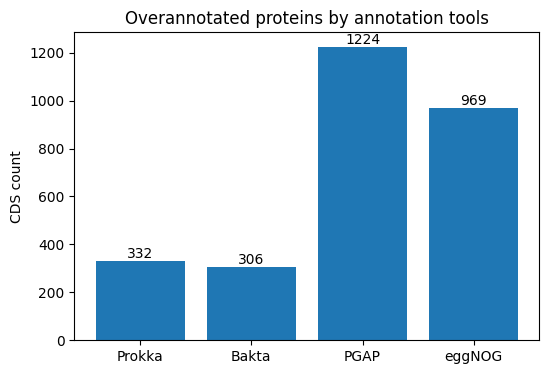

In [99]:
counts = [
    len(df_overannotated_prokka),
    len(df_overannotated_bakta),
    len(df_overannotated_pgap),
    len(df_overannotated_eggnog)
]


fig, ax = plt.subplots(figsize=(6,4))

bars = ax.bar(labels, counts)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )

ax.set_ylabel("CDS count")
ax.set_title("Overannotated proteins by annotation tools")

plt.show()

### 3. Reference vs PROKKA

In PROKKA's dataframe, we observe that 332 proteins were better annotated. Most of these proteins were mismatches: cases in which the UniProt IDs differ between the tool and the reference.

In [100]:
df_overannotated_prokka

,orf_id,product_Prokka,product_Reference,is_info_Prokka,is_info_Reference,UniProt_Prokka,UniProt_Reference,Cluster_Prokka,Cluster_Reference
16,25221_25766_-,Vibriobactin-specific isochorismatase,putative amidase (isochorismatase family),True,False,P0C6D3,P37532,UniRef100_P0C6D3,UniRef100_P37532
25,36478_37638_+,TelA-like protein,putative toxic compound resistance protein,True,False,P60108,P37535,UniRef100_P60107,UniRef100_P37535
26,37720_39162_+,Arginine decarboxylase,putative decarboxylase,True,False,P21885,P37536,UniRef100_P21885,UniRef100_P37536
43,52763_53023_+,Protein Veg,hypothetical protein,True,False,P37466,P37466,UniRef100_P37466,UniRef100_P37466
56,64817_66415_+,Lipid II flippase MurJ,putative exporter,True,False,O34674,P37555,UniRef100_O34674,UniRef100_P37555
...,...,...,...,...,...,...,...,...,...
4199,4180564_4181442_+,HTH-type transcriptional regulator GltC,putative transcriptional regulator (LysR family),True,False,P20668,P37499,UniRef100_P20668,UniRef100_P37499
4202,4182636_4183298_-,Hydroxyacylglutathione hydrolase,putative hydrolase,True,False,O31628,P37502,UniRef100_O31628,UniRef100_P37502
4206,4185160_4185681_-,Streptothricin acetyltransferase A,putative acetyl-transferase,True,False,P37506,P37506,UniRef100_P37506,UniRef100_P37506
4214,4191198_4193267_+,Cellobiose 2-epimerase,hypothetical protein,True,False,P37508,P37512,UniRef100_P37508,UniRef100_P37512


However, some proteins (57 CDS in this case) obtained the same UniProt ID but are described in a more informative way only in PROKKA. In this case, the different descriptions exist because the Reference uses the NCBI database and PROKKA mainly uses UniProt. (Some examples from this table are: P80869 and NP_388165.1, O34482 and NP_388151.1) 

In [101]:
df_filtered_prokka = df_overannotated_prokka[
    df_overannotated_prokka["UniProt_Prokka"] == df_overannotated_prokka["UniProt_Reference"]
]

print(df_filtered_prokka.shape)
df_filtered_prokka.head()

(57, 9)


,orf_id,product_Prokka,product_Reference,is_info_Prokka,is_info_Reference,UniProt_Prokka,UniProt_Reference,Cluster_Prokka,Cluster_Reference
43,52763_53023_+,Protein Veg,hypothetical protein,True,False,P37466,P37466,UniRef100_P37466,UniRef100_P37466
269,290915_292042_+,L-asparaginase 2,L-asparaginase 2 (putative lipoprotein),True,False,O34482,O34482,UniRef100_O34482,UniRef100_O34482
284,305658_306434_+,Glucose 1-dehydrogenase 2,putative oxidoreductase,True,False,P80869,P80869,UniRef100_P80869,UniRef100_P80869
290,312159_312758_+,Stress response protein SCP2,putative stress adaptation protein (tellurite ...,True,False,P81100,P81100,UniRef100_P81100,UniRef100_P81100
291,312780_313361_+,General stress protein 16U,putative stress adaptation protein (tellurite ...,True,False,P80875,P80875,UniRef100_P80875,UniRef100_P80875


When the description is hypothetical only in Reference, we have concordant and discordant matches in Uniprot IDs. For concordant matches in ID, the description comes from the same sources: PROKKA = Uniprot and Reference = NCBI. (Ex: O34763 and NP_389216.1). 

In [102]:
df_hypothetical_prokka = df_overannotated_prokka[
    df_overannotated_prokka["product_Reference"].str.lower().eq("hypothetical protein")
]

print(df_hypothetical_prokka.shape)
df_hypothetical_prokka.head(9)

(9, 9)


,orf_id,product_Prokka,product_Reference,is_info_Prokka,is_info_Reference,UniProt_Prokka,UniProt_Reference,Cluster_Prokka,Cluster_Reference
43,52763_53023_+,Protein Veg,hypothetical protein,True,False,P37466,P37466,UniRef100_P37466,UniRef100_P37466
490,528129_528581_+,Protein SprT-like protein,hypothetical protein,True,False,P46837,P96628,UniRef100_P46837,UniRef100_P96628
1121,1182448_1183032_-,Sporulation delaying protein C,hypothetical protein,True,False,O34344,O06748,UniRef100_O34344,UniRef100_O06748
1368,1398181_1398363_+,Stress response protein YkoL,hypothetical protein,True,False,O34763,O34763,UniRef100_O34763,UniRef100_O34763
2339,2366347_2367618_-,Beta-barrel assembly-enhancing protease,hypothetical protein,True,False,Q81SV3,P54389,UniRef100_Q81SV3,UniRef100_P54389
2577,2576717_2577181_+,Endolytic murein transglycosylase,hypothetical protein,True,False,A0R2E2,O32023,UniRef100_A0R2E2,UniRef100_O32023
2986,2951490_2951882_+,Sigma-w pathway protein YsdB,hypothetical protein,True,False,P94520,P94520,UniRef100_P94520,UniRef100_P94520
3031,2997301_2998620_-,Inosine-5'-monophosphate dehydrogenase,hypothetical protein,True,False,O34600,O34921,UniRef100_O34600,UniRef100_O34921
4214,4191198_4193267_+,Cellobiose 2-epimerase,hypothetical protein,True,False,P37508,P37512,UniRef100_P37508,UniRef100_P37512


For discordant matches, the new Uniprot ID for Reference have the same gene from the inicial NCBI ID for the reference (ex: NP_390373.2 --> O32023 are the same gene yqzC. However O32023 and A0R2E2 are different genes - a mismatch)

In [103]:
df_hypothetical_prokka[df_hypothetical_prokka["UniProt_Reference"] != df_hypothetical_prokka["UniProt_Prokka"]]

,orf_id,product_Prokka,product_Reference,is_info_Prokka,is_info_Reference,UniProt_Prokka,UniProt_Reference,Cluster_Prokka,Cluster_Reference
490,528129_528581_+,Protein SprT-like protein,hypothetical protein,True,False,P46837,P96628,UniRef100_P46837,UniRef100_P96628
1121,1182448_1183032_-,Sporulation delaying protein C,hypothetical protein,True,False,O34344,O06748,UniRef100_O34344,UniRef100_O06748
2339,2366347_2367618_-,Beta-barrel assembly-enhancing protease,hypothetical protein,True,False,Q81SV3,P54389,UniRef100_Q81SV3,UniRef100_P54389
2577,2576717_2577181_+,Endolytic murein transglycosylase,hypothetical protein,True,False,A0R2E2,O32023,UniRef100_A0R2E2,UniRef100_O32023
3031,2997301_2998620_-,Inosine-5'-monophosphate dehydrogenase,hypothetical protein,True,False,O34600,O34921,UniRef100_O34600,UniRef100_O34921
4214,4191198_4193267_+,Cellobiose 2-epimerase,hypothetical protein,True,False,P37508,P37512,UniRef100_P37508,UniRef100_P37512


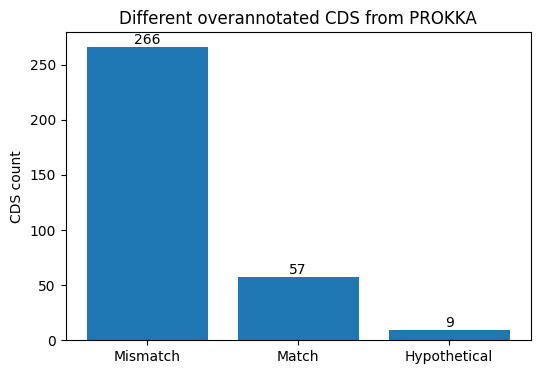

In [105]:
labels = ["Mismatch", "Match", "Hypothetical"]

counts = [
    len(df_overannotated_prokka) - (len(df_filtered_prokka) + len(df_hypothetical_prokka)),
    len(df_filtered_prokka),
    len(df_hypothetical_prokka)
]

fig, ax = plt.subplots(figsize=(6,4))

bars = ax.bar(labels, counts)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )

ax.set_ylabel("CDS count")
ax.set_title("Different overannotated CDS from PROKKA")

plt.show()

### 4. Reference vs PGAP

In [ ]:
df_overannotated_pgap

,orf_id,product_PGAP,product_Reference,is_info_PGAP,is_info_Reference,UniProt_PGAP,UniProt_Reference,Cluster_PGAP,Cluster_Reference,PGAP_RefSeq
7,14847_15794_-,YaaC family protein,hypothetical protein,True,False,P37526,P37526,UniRef100_P37526,UniRef100_P37526,NP_387889.1
16,25221_25766_-,isochorismatase family cysteine hydrolase,putative amidase (isochorismatase family),True,False,P37532,P37532,UniRef100_P37532,UniRef100_P37532,NP_387898.1
21,29481_29705_+,YaaL family protein,hypothetical protein,True,False,P37533,P37533,UniRef100_P37533,UniRef100_P37533,NP_387903.1
24,35845_36459_+,5-bromo-4-chloroindolyl phosphate hydrolysis f...,putative phosphatase,True,False,P37467,P37467,UniRef100_P37467,UniRef100_P37467,NP_387906.1
25,36478_37638_+,toxic anion resistance protein,putative toxic compound resistance protein,True,False,P37535,P37535,UniRef100_P37535,UniRef100_P37535,NP_387907.1
...,...,...,...,...,...,...,...,...,...,...
4216,4194389_4195744_+,MFS transporter,putative transporter,True,False,P37514,P37514,UniRef100_P37514,UniRef100_P37514,NP_391964.2
4218,4196350_4196730_-,VOC family protein,putative C-S lyase,True,False,P37516,P37516,UniRef100_P37516,UniRef100_P37516,NP_391966.1
4225,4201070_4203073_-,molybdopterin-dependent oxidoreductase,putative oxidoreductase (molybdoenzyme),True,False,A0ABM5M3B4,P37519,UniRef100_A0ABM5M3B4,UniRef100_P37519,WP_013390719.1
4227,4203424_4204440_-,YkvI family membrane protein,putative transporter,True,False,P37520,P37520,UniRef100_P37520,UniRef100_P37520,NP_391974.1


In [106]:
df_filtered_pgap = df_overannotated_pgap[
    df_overannotated_pgap["UniProt_PGAP"] == df_overannotated_pgap["UniProt_Reference"]
]

print(df_filtered_pgap.shape)
df_filtered_pgap.head()

(1161, 10)


,orf_id,product_PGAP,product_Reference,is_info_PGAP,is_info_Reference,UniProt_PGAP,UniProt_Reference,Cluster_PGAP,Cluster_Reference,PGAP_RefSeq
7,14847_15794_-,YaaC family protein,hypothetical protein,True,False,P37526,P37526,UniRef100_P37526,UniRef100_P37526,NP_387889.1
16,25221_25766_-,isochorismatase family cysteine hydrolase,putative amidase (isochorismatase family),True,False,P37532,P37532,UniRef100_P37532,UniRef100_P37532,NP_387898.1
21,29481_29705_+,YaaL family protein,hypothetical protein,True,False,P37533,P37533,UniRef100_P37533,UniRef100_P37533,NP_387903.1
24,35845_36459_+,5-bromo-4-chloroindolyl phosphate hydrolysis f...,putative phosphatase,True,False,P37467,P37467,UniRef100_P37467,UniRef100_P37467,NP_387906.1
25,36478_37638_+,toxic anion resistance protein,putative toxic compound resistance protein,True,False,P37535,P37535,UniRef100_P37535,UniRef100_P37535,NP_387907.1


In [107]:
df_hypothetical_pgap = df_overannotated_pgap[
    df_overannotated_pgap["product_Reference"].str.lower().eq("hypothetical protein")
]

print(df_hypothetical_pgap.shape)
df_hypothetical_pgap.head()

(237, 10)


,orf_id,product_PGAP,product_Reference,is_info_PGAP,is_info_Reference,UniProt_PGAP,UniProt_Reference,Cluster_PGAP,Cluster_Reference,PGAP_RefSeq
7,14847_15794_-,YaaC family protein,hypothetical protein,True,False,P37526,P37526,UniRef100_P37526,UniRef100_P37526,NP_387889.1
21,29481_29705_+,YaaL family protein,hypothetical protein,True,False,P37533,P37533,UniRef100_P37533,UniRef100_P37533,NP_387903.1
29,40213_40653_+,YaaR family protein,hypothetical protein,True,False,P37539,P37539,UniRef100_P37539,UniRef100_P37539,NP_387911.1
43,52763_53023_+,biofilm formation stimulator Veg,hypothetical protein,True,False,P37466,P37466,UniRef100_P37466,UniRef100_P37466,NP_387925.1
64,73106_73843_+,VWA domain-containing protein,hypothetical protein,True,False,P37561,P37561,UniRef100_P37561,UniRef100_P37561,NP_387946.1


In [108]:
df_hypothetical_pgap[df_hypothetical_pgap["UniProt_Reference"] != df_hypothetical_pgap["UniProt_PGAP"]]

,orf_id,product_PGAP,product_Reference,is_info_PGAP,is_info_Reference,UniProt_PGAP,UniProt_Reference,Cluster_PGAP,Cluster_Reference,PGAP_RefSeq
1364,1395371_1395508_+,transcriptional regulator SplA domain-containi...,hypothetical protein,True,False,NaN,O34405,NaN,UniRef100_O34405,WP_006638487.1
1368,1398181_1398363_+,stress response protein YkoL,hypothetical protein,True,False,A0A6M3ZF91,O34763,UniRef100_O34763,UniRef100_O34763,NP_389216.1
2247,2290078_2290272_-,protein YpmT,hypothetical protein,True,False,A0A6M3ZIE3,P54180,UniRef100_P54180,UniRef100_P54180,NP_390055.1
2783,2751292_2751651_-,SH3 domain-containing protein,hypothetical protein,True,False,A0A6M4JM69,O07909,UniRef100_O07909,UniRef100_O07909,NP_390570.2
2854,2818191_2818361_-,YrzK family protein,hypothetical protein,True,False,A0A6M4JKG6,O32040,UniRef100_O32040,UniRef100_O32040,NP_390635.1
2986,2951490_2951882_+,sigma W pathway protein YsdB,hypothetical protein,True,False,A0A6M4JKL3,P94520,UniRef100_P94520,UniRef100_P94520,NP_390761.1
3537,3513887_3514105_+,protein YvfG,hypothetical protein,True,False,A0A6M4JPD9,P71066,UniRef100_P71066,UniRef100_P71066,NP_391301.1
3917,3895805_3896122_-,YwdI family protein,hypothetical protein,True,False,A0A6M3ZH76,P39617,UniRef100_P39617,UniRef100_P39617,NP_391674.3
4148,4132338_4132736_-,ABC-three component system middle component 6,hypothetical protein,True,False,NaN,Q45599,NaN,UniRef100_Q45599,NF042477.4


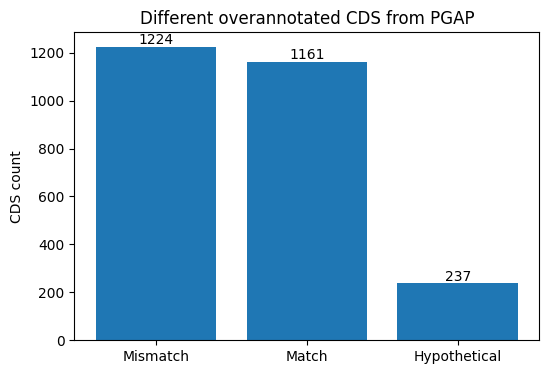

In [110]:
labels = ["Mismatch", "Match", "Hypothetical"]

counts = [
    len(df_overannotated_pgap),
    len(df_filtered_pgap),
    len(df_hypothetical_pgap)
]

fig, ax = plt.subplots(figsize=(6,4))

bars = ax.bar(labels, counts)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )

ax.set_ylabel("CDS count")
ax.set_title("Different overannotated CDS from PGAP")

plt.show()